In [37]:
!pip install transformer-lens circuitsvis -q

In [38]:
!pip install  sae-lens datasets wandb numpy

In [39]:
import torch
import gc
from transformer_lens import HookedTransformer
import random
import os
# from google.colab import drive
from sae_lens import (
    LanguageModelSAERunnerConfig,
    LanguageModelSAETrainingRunner,
    StandardTrainingSAEConfig,
    TopKTrainingSAEConfig
)
from pathlib import Path
from sae_lens import SAE

from transformers import AutoModelForCausalLM, AutoTokenizer, Trainer, TrainingArguments, DataCollatorForLanguageModeling, TrainerCallback
from datasets import load_dataset

from transformers import AutoModelForCausalLM, AutoTokenizer

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment

# from sae_dashboard.sae_vis_data import SaeVisConfig
# from sae_dashboard.sae_vis_runner import SaeVisRunner


from transformer_lens import HookedTransformer
from datasets import load_dataset
from collections import defaultdict
import inspect
# from sae_dashboard.sae_vis_data import SaeVisConfig
# from sae_dashboard.sae_vis_runner import SaeVisRunner
from sae_lens import SAE

from transformer_lens import HookedTransformer

from scipy.optimize import linear_sum_assignment
import wandb

from sae_lens.config import LoggingConfig

from sae_lens import LanguageModelSAERunnerConfig

from sae_lens.config import LoggingConfig

In [40]:
SEED = 42
torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

In [41]:


os.environ["WANDB_API_KEY"] = "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"
wandb.login()

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


False

In [42]:
class NaNChecker(TrainerCallback):
    def on_step_end(self, args, state, control, model=None, **kwargs):
        for name, param in model.named_parameters():
            if param.grad is not None and torch.isnan(param.grad).any():
                print(f"🚨 NaN gradient at step {state.global_step} in {name}")
                control.should_training_stop = True
                break
            if torch.isnan(param).any():
                print(f"🚨 NaN weight at step {state.global_step} in {name}")
                control.should_training_stop = True
                break

In [43]:


def tokenize_function(examples):
    text = [f"Instruction: {i}\nCode:\n{c}" for i, c in zip(examples['instruction'], examples['output'])]
    return tokenizer(text, truncation=True, max_length=1024, padding="max_length")


In [44]:
gc.collect()
torch.cuda.empty_cache()
print("GPU memory completely flushed. Ready for a clean start!")

GPU memory completely flushed. Ready for a clean start!


In [9]:
# drive.mount('/content/drive')

NotImplementedError: Mounting drive is unsupported in this environment. Use PyDrive2 instead. See examples at https://colab.research.google.com/notebooks/io.ipynb#scrollTo=7taylj9wpsA2.

In [45]:
model = HookedTransformer.from_pretrained("pythia-160m") #Loading Pythia-160M
prompt = "The capital of France is"
logits = model(prompt)
print(logits.shape)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded pretrained model pythia-160m into HookedTransformer
torch.Size([1, 5, 50304])


In [46]:
import inspect
print(inspect.signature(model.generate))

(input: "Union[str, List[str], Int[torch.Tensor, 'batch pos'], Float[torch.Tensor, 'batch pos hidden_size']]" = '', max_new_tokens: 'int' = 10, stop_at_eos: 'bool' = True, eos_token_id: 'Optional[int]' = None, do_sample: 'bool' = True, top_k: 'Optional[int]' = None, top_p: 'Optional[float]' = None, temperature: 'float' = 1.0, freq_penalty: 'float' = 0.0, use_past_kv_cache: 'bool' = True, prepend_bos: 'Optional[bool]' = None, padding_side: "Optional[Literal['left', 'right']]" = None, return_type: 'Optional[str]' = 'input', verbose: 'bool' = True, **generation_kwargs) -> "Union[str, List[str], Int[torch.Tensor, 'batch pos_plus_new_tokens'], Float[torch.Tensor, 'batch pos_plus_new_tokens hidden_size'], Any]"


In [19]:
output = model.generate(prompt,max_new_tokens = 20)
print(output)

  0%|          | 0/20 [00:00<?, ?it/s]

The capital of France is in Marseille but just over 100 kilometres from Sofia on the Greek coast. Originally known as


In [11]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


### FINE TUNING THE MODEL
- ON PYTHON CODE

FINETUNED MODEL

In [ ]:
model_name = "EleutherAI/pythia-160m"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.padding_side = "right"
tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained(model_name)
dataset = load_dataset("flytech/python-codes-25k", split="train[:5000]")
tokenized_dataset = dataset.map(
    tokenize_function,
    batched=True,
    batch_size=250,
    writer_batch_size=500,
    remove_columns=dataset.column_names
)
tokenized_dataset = tokenized_dataset.train_test_split(test_size=0.1)
drive_output_dir = "/kaggle/input/datasets/ritwik8307/pythia-python-finetuned"
training_args = TrainingArguments(
    output_dir=drive_output_dir,
    num_train_epochs=1,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,
    learning_rate=5e-6,
    weight_decay=0.01,
    logging_steps=25,
    save_strategy="steps",
    save_steps = 100,
    save_total_limit =3,
    eval_strategy="steps",
    eval_steps=100,
    fp16=False,
    bf16=False,
    report_to="wandb",
    run_name="pythia_python_finetune",
    max_grad_norm=0.5,
    warmup_steps=200,
    lr_scheduler_type="cosine",
)
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"],
    data_collator=data_collator,
    callbacks=[NaNChecker()]
)
trainer.args.overwrite_output_dir = True
print("Starting Fine-Tuning")
trainer.train()
final_model_path = os.path.join(drive_output_dir, "final_model")
model.save_pretrained(final_model_path)
tokenizer.save_pretrained(final_model_path)
print(f"Fine-tuning complete. Saved to: {final_model_path}")


In [47]:


!ls -lh /kaggle/input/datasets/ritwik8307/pythia-python-finetuned/final_model

total 623M
-rw-r--r-- 1 nobody nogroup  751 Jun  3 12:10 config.json
-rw-r--r-- 1 nobody nogroup  111 Jun  3 12:10 generation_config.json
-rw-r--r-- 1 nobody nogroup 620M Jun  3 12:10 model.safetensors
-rw-r--r-- 1 nobody nogroup  473 Jun  3 12:10 special_tokens_map.json
-rw-r--r-- 1 nobody nogroup 4.8K Jun  3 12:10 tokenizer_config.json
-rw-r--r-- 1 nobody nogroup 3.4M Jun  3 12:10 tokenizer.json


In [23]:

params = inspect.signature(LanguageModelSAERunnerConfig).parameters
wandb_params = [p for p in params if 'wandb' in p.lower() or 'log' in p.lower()]
print(wandb_params)
print(params)

['logger']
OrderedDict({'sae': <Parameter "sae: +T_TRAINING_SAE_CONFIG">, 'model_name': <Parameter "model_name: str = 'gelu-2l'">, 'model_class_name': <Parameter "model_class_name: str = 'HookedTransformer'">, 'hook_name': <Parameter "hook_name: str = 'blocks.0.hook_mlp_out'">, 'hook_eval': <Parameter "hook_eval: str = 'NOT_IN_USE'">, 'hook_head_index': <Parameter "hook_head_index: int | None = None">, 'dataset_path': <Parameter "dataset_path: str = ''">, 'dataset_trust_remote_code': <Parameter "dataset_trust_remote_code: bool = True">, 'streaming': <Parameter "streaming: bool = True">, 'is_dataset_tokenized': <Parameter "is_dataset_tokenized: bool = True">, 'use_chat_formatting': <Parameter "use_chat_formatting: bool = False">, 'context_size': <Parameter "context_size: int = 128">, 'use_cached_activations': <Parameter "use_cached_activations: bool = False">, 'cached_activations_path': <Parameter "cached_activations_path: str | None = None">, 'from_pretrained_path': <Parameter "from_pr

In [24]:


print(inspect.signature(LoggingConfig))

(log_to_wandb: bool = True, log_activations_store_to_wandb: bool = False, log_optimizer_state_to_wandb: bool = False, log_weights_to_wandb: bool = True, wandb_project: str = 'sae_lens_training', wandb_id: str | None = None, run_name: str | None = None, wandb_entity: str | None = None, wandb_log_frequency: int = 10, eval_every_n_wandb_logs: int = 100) -> None


SAE Loggers

In [49]:


logger_base = LoggingConfig(
    log_to_wandb=True,
    wandb_project="sae-comparison",
    run_name="sae_base",
    wandb_log_frequency=50,
)


logger_fine = LoggingConfig(
    log_to_wandb=True,
    wandb_project="sae-comparison",
    run_name="sae_fine",
    wandb_log_frequency=50,
)

In [50]:
# Before SAE training, compute activation statistics on a sample:
# Collect ~2000 tokens worth of activations from the base model
model = HookedTransformer.from_pretrained("pythia-160m")
dataset = load_dataset("Skylion007/openwebtext", split="train", streaming=True)

sample_acts = []
for i, example in enumerate(dataset):
    if i >= 50: break  # 50 passages is enough for stable stats
    tokens = model.to_tokens(example["text"][:300], prepend_bos=True)
    with torch.no_grad():
        _, cache = model.run_with_cache(tokens)
    sample_acts.append(cache["blocks.8.hook_resid_post"].squeeze(0))

acts_sample = torch.cat(sample_acts, dim=0)  # [~2000_tokens, 768]

# Now compute normalization stats
activation_mean = acts_sample.mean(dim=0)          # [768]
activation_std  = acts_sample.std(dim=0).clamp(1e-8)  # [768]


activation_mean = acts_sample.mean(dim=0, keepdim=True)
activation_std  = acts_sample.std(dim=0, keepdim=True).clamp(min=1e-8)
normalized_acts = (acts_sample - activation_mean) / activation_std

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded pretrained model pythia-160m into HookedTransformer


Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

SAE #1
  on normal model


In [ ]:

print(inspect.signature(TopKTrainingSAEConfig))

(d_in: int, d_sae: int, dtype: str = 'float32', device: str = 'cpu', apply_b_dec_to_input: bool = True, normalize_activations: Literal['none', 'expected_average_only_in', 'layer_norm'] = 'none', reshape_activations: Literal['none', 'hook_z'] = 'none', metadata: sae_lens.saes.sae.SAEMetadata = <factory>, k: int = 100, use_sparse_activations: bool = False, aux_loss_coefficient: float = 1.0, rescale_acts_by_decoder_norm: bool = True, *, decoder_init_norm: float | None = 0.1) -> None


In [51]:

sae_cfg_base = TopKTrainingSAEConfig(
    d_in=768,
    d_sae=768 * 4,
    k=32,
    aux_loss_coefficient=1.0,
    rescale_acts_by_decoder_norm=True,
    normalize_activations="expected_average_only_in"
)

cfg_base = LanguageModelSAERunnerConfig(
    model_name="pythia-160m",
    hook_name="blocks.8.hook_resid_post",


    dataset_path="Skylion007/openwebtext",
    is_dataset_tokenized=False,
    context_size=512,
    train_batch_size_tokens=4096,

    n_batches_in_buffer=8,
    store_batch_size_prompts=2,

    training_tokens=50_000_000,
    lr=5e-5,
    dtype="float32",
    n_checkpoints=5,
    checkpoint_path="/kaggle/input/datasets/ritwik8307/sae-pythia-checkpoints",
    device="cuda" if torch.cuda.is_available() else "cpu",

    logger=logger_base,
    seed = SEED,

    sae=sae_cfg_base
)

torch.cuda.empty_cache()

runner = LanguageModelSAETrainingRunner(cfg_base)



Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'Skylion007/openwebtext' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loaded pretrained model pythia-160m into HookedTransformer


Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

FINE TUNING WAS INCORRECT< need to implement gradient clipping there or retrain with lower lr

SAE #2

In [52]:


# Define target paths
ft_model_dir = "/kaggle/input/datasets/ritwik8307/pythia-python-finetuned/final_model"
ft_sae_save_dir = "/kaggle/input/datasets/ritwik8307/sae-finetuned-checkpoints"
os.makedirs(ft_sae_save_dir, exist_ok=True)


sae_cfg_fine = TopKTrainingSAEConfig(
    d_in=768,
    d_sae=768 * 4,
    k=32,
    aux_loss_coefficient=1.0,
    rescale_acts_by_decoder_norm=True,
    normalize_activations="expected_average_only_in"
)

# 3. SAELens Runner Config
cfg_fine = LanguageModelSAERunnerConfig(
    model_name="pythia-160m",
    hook_name="blocks.8.hook_resid_post",
    dataset_path="Skylion007/openwebtext",
    is_dataset_tokenized=False,
    context_size=512,
    train_batch_size_tokens=4096,
    n_batches_in_buffer=8,
    store_batch_size_prompts=2,
    training_tokens=50_000_000,
    lr=5e-5,
    dtype="float32",
    n_checkpoints=5,
    checkpoint_path=ft_sae_save_dir,
    device="cuda" if torch.cuda.is_available() else "cpu",

    logger=logger_fine,
    seed= SEED,
    sae=sae_cfg_fine
)


print("Step 1: Loading raw fine-tuned weights into RAM...")
raw_hf_model = AutoModelForCausalLM.from_pretrained(ft_model_dir)

print("Step 2: Transplanting weights into a HookedTransformer...")
custom_hooked_model = HookedTransformer.from_pretrained(
    model_name="pythia-160m",    
    hf_model=raw_hf_model,          
    device=cfg_fine.device,
    dtype = torch.float32
)


print("Step 3: Initializing SAE Runner with our custom model...")

runner_fine = LanguageModelSAETrainingRunner(cfg_fine, override_model=custom_hooked_model)


Step 1: Loading raw fine-tuned weights into RAM...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Step 2: Transplanting weights into a HookedTransformer...


You just passed in a model which will override the one specified in your configuration: pythia-160m. As a consequence this run will not be reproducible via configuration alone.
`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'Skylion007/openwebtext' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Loaded pretrained model pythia-160m into HookedTransformer
Step 3: Initializing SAE Runner with our custom model...


Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

In [53]:
# Check if the model even generates coherent text

tokenizer = AutoTokenizer.from_pretrained("EleutherAI/pythia-160m")
ft_hf = AutoModelForCausalLM.from_pretrained(
    ft_model_dir
)

inputs = tokenizer("def fibonacci(n):", return_tensors="pt")
with torch.no_grad():
    outputs = ft_hf.generate(**inputs, max_new_tokens=30)
print(tokenizer.decode(outputs[0]))

# Also check weight norms directly
for name, param in ft_hf.named_parameters():
    norm = param.norm().item()
    if norm > 1000:
        print(f" Exploded layer: {name}, norm={norm:.1f}")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

def fibonacci(n):
    return sum(n)

# Example:
# 1. Let me examine if the sum of the Fibonacci numbers is equal


CHECKING FOR NANs

In [54]:
tokens = torch.randint(0, 1000, (4, 128)).to(cfg_fine.device)

# Fine-tuned model activations
with torch.no_grad():
    _, cache_ft = custom_hooked_model.run_with_cache(tokens)
    acts_ft = cache_ft["blocks.8.hook_resid_post"]

# Base model activations
base_model = HookedTransformer.from_pretrained("pythia-160m", device=cfg_base.device)
with torch.no_grad():
    _, cache_base = base_model.run_with_cache(tokens)
    acts_base = cache_base["blocks.8.hook_resid_post"]

print("Mean activation norm (base):", acts_base.norm(dim=-1).mean().item())
print("Mean activation norm (ft):  ", acts_ft.norm(dim=-1).mean().item())

print("  FINE-TUNED MODEL ")
print(f"mean:    {acts_ft.mean().item():.4f}")
print(f"std:     {acts_ft.std().item():.4f}")
print(f"max abs: {acts_ft.abs().max().item():.4f}")
print(f"has nan: {torch.isnan(acts_ft).any().item()}")
print(f"has inf: {torch.isinf(acts_ft).any().item()}")

print("\n BASE MODEL ")
print(f"mean:    {acts_base.mean().item():.4f}")
print(f"std:     {acts_base.std().item():.4f}")
print(f"max abs: {acts_base.abs().max().item():.4f}")
print(f"has nan: {torch.isnan(acts_base).any().item()}")
print(f"has inf: {torch.isinf(acts_base).any().item()}")







nan_params = [(n, p) for n, p in custom_hooked_model.named_parameters()
              if torch.isnan(p).any()]
print("Corrupt layers:", [n for n, _ in nan_params])

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded pretrained model pythia-160m into HookedTransformer
Mean activation norm (base): 29.348224639892578
Mean activation norm (ft):   28.946523666381836
  FINE-TUNED MODEL 
mean:    0.0000
std:     1.6367
max abs: 284.0477
has nan: False
has inf: False

 BASE MODEL 
mean:    -0.0000
std:     1.6340
max abs: 283.1782
has nan: False
has inf: False
Corrupt layers: []


TRAINING SAEs

In [ ]:
#SAE 1 Training
sae_base = runner.run()


torch.save(sae_base.state_dict(), "/kaggle/input/datasets/ritwik8307/sae-finetuned-checkpoints/final_ft_sae.pt")
print("SAE Successfully trained and secured!")




Training SAE:   0%|          | 0/50000000 [00:00<?, ?it/s]

Estimating norm scaling factor:   0%|          | 0/1000 [00:00<?, ?it/s]

details/current_learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
details/n_training_samples,▁▁▁▁▁▂▂▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇██
losses/auxiliary_reconstruction_loss,▁▁▁█▇▆▅▅▅▅▅▅▅▅▅▅▄▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
losses/mse_loss,█▅▄▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
losses/overall_loss,█▇▆▄▄▆▅▄▄▄▄▄▄▃▃▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
metrics/explained_variance,▁▄▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇█▇▇▇██▇███▇████████
metrics/explained_variance_legacy,▁▃▃▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇████▇████████
metrics/explained_variance_legacy_std,▇█▃▃▂▃▃▂▃▄▂▃▂▂▂▂▂▂▂▂▂▁▁▂▁▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁
metrics/l0,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
metrics/mean_log10_feature_sparsity,▅▁▅▇▇█
+4,...


SAE Successfully trained and secured!


In [16]:
#SAE 2 Training


print("Step 4: Training SAE...")
sae_finetuned = runner_fine.run()

ft_sae_save_dir = "/kaggle/input/datasets/ritwik8307/sae-finetuned-checkpoints"

final_ft_sae_file = os.path.join(ft_sae_save_dir, "final_ft_sae.pt")
torch.save(sae_finetuned.state_dict(), final_ft_sae_file)
print(f"SUCCESS: Fine-Tuned SAE completely trained and secured at: {final_ft_sae_file}")

Step 4: Training SAE...


Training SAE:   0%|          | 0/50000000 [00:00<?, ?it/s]

Estimating norm scaling factor:   0%|          | 0/1000 [00:00<?, ?it/s]

details/current_learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
details/n_training_samples,▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇████
losses/auxiliary_reconstruction_loss,▁▁▁▁█▇▇▆▆▆▅▅▅▆▆▆▅▆▄▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
losses/mse_loss,█▆▄▃▃▂▂▂▂▂▂▂▂▂▂▂▁▂▁▁▁▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
losses/overall_loss,█▅▅▃▃▄▃▃▃▃▃▃▃▃▃▃▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
metrics/explained_variance,▁▂▂▃▅▇▇▇▇▇▇▇▇▇▇█████████████████████████
metrics/explained_variance_legacy,▁▁▄▄▄▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇█████▇████████
metrics/explained_variance_legacy_std,█▅▇▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▂▁▁▁▂▁▁▁▁▁▁▁▁▁▂▁▂
metrics/l0,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
metrics/mean_log10_feature_sparsity,▅▁▆▇▇█
+4,...


SUCCESS: Fine-Tuned SAE completely trained and secured at: /kaggle/working/sae_finetuned_checkpoints/final_ft_sae.pt


VERIFICATION

In [55]:
# FOR SAE 1
drive_save_dir = "/kaggle/input/datasets/ritwik8307/sae-pythia-checkpoints"
final_file = os.path.join(drive_save_dir, "final_sae.pt")


if os.path.exists(final_file):
    size_mb = os.path.getsize(final_file) / (1024 * 1024)
    print(f"Found Final SAE Weights: {final_file} ({size_mb:.2f} MB)")
else:
    print(f"Final SAE Weights NOT found at {final_file}")

if os.path.exists(drive_save_dir):
    print("\nChecking Checkpoint Folders:")
    for item in os.listdir(drive_save_dir):
        item_path = os.path.join(drive_save_dir, item)
        if os.path.isdir(item_path):
            print(f"  • Found Checkpoint Folder: {item}")

try:
    state_dict = torch.load(final_file, map_location="cpu")
    print("\nVerification Success: Successfully loaded state_dict parameters into memory!")
    print(f"Tensor keys found: {list(state_dict.keys())[:3]}... (Total keys: {len(state_dict)})")
except Exception as e:
    print(f"\nLoad Verification Failed: {e}")


--- Checking Google Drive Storage ---
Found Final SAE Weights: /kaggle/input/datasets/ritwik8307/sae-pythia-checkpoints/final_sae.pt (18.02 MB)

Checking Checkpoint Folders:

Verification Success: Successfully loaded state_dict parameters into memory!
Tensor keys found: ['b_dec', 'W_dec', 'W_enc']... (Total keys: 4)


In [59]:
# FOR SAE 2


drive_save_dir = "/kaggle/input/datasets/ritwik8307/sae-finetuned-checkpoints"
final_file = os.path.join(drive_save_dir, "final_ft_sae.pt")
if os.path.exists(final_file):
    size_mb = os.path.getsize(final_file) / (1024 * 1024)
    print(f"Found Final SAE Weights: {final_file} ({size_mb:.2f} MB)")
else:
    print(f"Final SAE Weights NOT found at {final_file}")

if os.path.exists(drive_save_dir):
    print("\nChecking Checkpoint Folders:")
    for item in os.listdir(drive_save_dir):
        item_path = os.path.join(drive_save_dir, item)
        if os.path.isdir(item_path):
            print(f"  • Found Checkpoint Folder: {item}")


try:
    state_dict = torch.load(final_file, map_location="cpu")
    print("\nVerification Success: Successfully loaded state_dict parameters into memory!")
    print(f"Tensor keys found: {list(state_dict.keys())[:3]}... (Total keys: {len(state_dict)})")
except Exception as e:
    print(f"\nLoad Verification Failed: {e}")


Found Final SAE Weights: /kaggle/input/datasets/ritwik8307/sae-finetuned-checkpoints/final_ft_sae.pt (18.02 MB)

Checking Checkpoint Folders:

Verification Success: Successfully loaded state_dict parameters into memory!
Tensor keys found: ['b_dec', 'W_dec', 'W_enc']... (Total keys: 4)


DRAWING INSIGHTS


In [60]:

ckpt = torch.load(
    "/kaggle/input/datasets/ritwik8307/sae-finetuned-checkpoints/final_ft_sae.pt",
    map_location="cpu"
)

print(type(ckpt))

if isinstance(ckpt, dict):
    print(ckpt.keys())

<class 'collections.OrderedDict'>
odict_keys(['b_dec', 'W_dec', 'W_enc', 'b_enc'])


In [61]:

print("Loading SAE weights from .pt files...")

base_state = torch.load(
    "/kaggle/input/datasets/ritwik8307/sae-pythia-checkpoints/final_sae.pt",
    map_location="cpu"
)
ft_state = torch.load(
    "/kaggle/input/datasets/ritwik8307/sae-finetuned-checkpoints/final_ft_sae.pt",
    map_location="cpu"
)

print("Keys in base SAE:", list(base_state.keys()))
print("Keys in ft SAE:",   list(ft_state.keys()))

W1 = base_state["W_dec"].cpu().to(torch.float32)
W2 = ft_state["W_dec"].cpu().to(torch.float32)

# Ensure feature dimension is the first dimension
if W1.shape[0] < W1.shape[1]:
    W1 = W1.T
    W2 = W2.T

print(f"Base SAE decoder shape: {W1.shape}")
print(f"Fine-tuned SAE decoder shape: {W2.shape}")

# Cosine Similarity Matrix
print("Computing cosine similarity matrix...")
W1_n = W1 / W1.norm(dim=-1, keepdim=True)
W2_n = W2 / W2.norm(dim=-1, keepdim=True)

sim_matrix = W1_n @ W2_n.T



cost_matrix = 1.0 - sim_matrix.numpy()

# row_ind corresponds to Base SAE, col_ind corresponds to Fine-Tuned SAE
row_ind, col_ind = linear_sum_assignment(cost_matrix)


matched_similarities = sim_matrix[row_ind, col_ind].numpy()

# Feature Shift Analysis
print("\n Feature Analysis Results")
preserved = (matched_similarities >= 0.8).sum()
shifted = ((matched_similarities >= 0.4) & (matched_similarities < 0.8)).sum()
lost = (matched_similarities < 0.4).sum()

total = len(matched_similarities)
print(f"Total Features Evaluated: {total}")
print(f"Preserved (>0.80): {preserved} ({(preserved/total)*100:.1f}%)")
print(f"Shifted   (0.4-0.8): {shifted} ({(shifted/total)*100:.1f}%)")
print(f"Lost/New  (<0.40): {lost} ({(lost/total)*100:.1f}%)")

# "New" Python Domain Features
# Find the indices in SAE #2 that had terrible matches with SAE #1
unmatched_ft_indices = col_ind[matched_similarities < 0.2]
print(f"\nFound {len(unmatched_ft_indices)} highly unique domain features in SAE #2.")
print("Top 10 indices in SAE #2 to investigate for Python-specific behaviors:")
print(unmatched_ft_indices[:10])



Loading SAE weights from .pt files...
Keys in base SAE: ['b_dec', 'W_dec', 'W_enc', 'b_enc']
Keys in ft SAE: ['b_dec', 'W_dec', 'W_enc', 'b_enc']
Base SAE decoder shape: torch.Size([3072, 768])
Fine-tuned SAE decoder shape: torch.Size([3072, 768])
Computing cosine similarity matrix...

 Feature Analysis Results
Total Features Evaluated: 3072
Preserved (>0.80): 571 (18.6%)
Shifted   (0.4-0.8): 1628 (53.0%)
Lost/New  (<0.40): 873 (28.4%)

Found 303 highly unique domain features in SAE #2.
Top 10 indices in SAE #2 to investigate for Python-specific behaviors:
[1265 3046 1092  604 1321   95  943 1558 1655 2873]


In [62]:

# Best match per feature
best_match_score = sim_matrix.max(dim=1).values
print(best_match_score)

tensor([0.3966, 0.6655, 0.8143,  ..., 0.9210, 0.3389, 0.6442])


In [63]:

print("W1 norm stats:", W1.norm(dim=-1).mean().item(), W1.norm(dim=-1).std().item())
print("W2 norm stats:", W2.norm(dim=-1).mean().item(), W2.norm(dim=-1).std().item())


print("W1 near-zero rows:", (W1.norm(dim=-1) < 1e-6).sum().item())
print("W2 near-zero rows:", (W2.norm(dim=-1) < 1e-6).sum().item())

random_W = torch.randn_like(W1)
random_W = random_W / random_W.norm(dim=-1, keepdim=True)
W1_n = W1 / W1.norm(dim=-1, keepdim=True)
random_sim = (W1_n @ random_W.T).max(dim=1).values
print("Random baseline similarity:", random_sim.mean().item())
print("Your actual similarity:     ", best_match_score.mean().item())

W1 norm stats: 0.3177283704280853 0.09682236611843109
W2 norm stats: 0.313517302274704 0.09599833190441132
W1 near-zero rows: 0
W2 near-zero rows: 0
Random baseline similarity: 0.12810242176055908
Your actual similarity:      0.5793097615242004


In [64]:

lost_feature_indices = (best_match_score < 0.4).nonzero(as_tuple=True)[0]
print(f"Lost feature indices: {lost_feature_indices[:20]}")

preserved_indices = (best_match_score >= 0.95).nonzero(as_tuple=True)[0]
print(f"Highly preserved feature indices: {preserved_indices[:20]}")

Lost feature indices: tensor([  0,   7,  17,  27,  40,  42,  45,  47,  57,  61,  65,  69,  77,  83,
         87,  90,  94,  95,  98, 102])
Highly preserved feature indices: tensor([  88,  261,  487,  735,  771,  822,  846, 1030, 1110, 1113, 1124, 1239,
        1241, 1344, 1355, 1603, 1842, 1948, 2065, 2118])


In [65]:

best_match_ft = sim_matrix.max(dim=0).values

new_feature_indices = (best_match_ft < 0.4).nonzero(as_tuple=True)[0]
print(f"New domain-specific features in SAE #2: {len(new_feature_indices)}")
print(f"Top indices to investigate: {new_feature_indices[:10]}")

New domain-specific features in SAE #2: 693
Top indices to investigate: tensor([ 0,  7, 14, 17, 19, 28, 34, 35, 43, 46])


PIPELINE

In [66]:
#Build the Similarity Matrix

W1 = base_state["W_dec"].cpu().float()
W2 = ft_state["W_dec"].cpu().float()

if W1.shape[0] < W1.shape[1]: W1 = W1.T
if W2.shape[0] < W2.shape[1]: W2 = W2.T

# Normalize
W1_n = W1 / W1.norm(dim=-1, keepdim=True).clamp(min=1e-8)
W2_n = W2 / W2.norm(dim=-1, keepdim=True).clamp(min=1e-8)

# Full similarity matrix [n_features x n_features]
sim_matrix = W1_n @ W2_n.T

# Best match for each base feature
best_match_score, best_match_idx = sim_matrix.max(dim=1)

print(f"Mean similarity: {best_match_score.mean():.4f}")
print(f"Std:             {best_match_score.std():.4f}")

Mean similarity: 0.5793
Std:             0.2054


Quantitative Metrics

In [67]:
print(f"\nMean sim of preserved: {best_match_score[best_match_score >= 0.8].mean():.4f}")
print(f"Mean sim of shifted:   {best_match_score[(best_match_score >= 0.4) & (best_match_score < 0.8)].mean():.4f}")

best_match_from_ft = sim_matrix.max(dim=0).values
new_features = (best_match_from_ft < 0.4).sum().item()
print(f"\nNew features in SAE #2 (no match in base): {new_features} ({new_features/total*100:.1f}%)")


Mean sim of preserved: 0.8785
Mean sim of shifted:   0.5882

New features in SAE #2 (no match in base): 693 (22.6%)


In [73]:


# Load both models
base_model = HookedTransformer.from_pretrained("pythia-160m", device="cpu")

from transformers import AutoModelForCausalLM
raw_ft = AutoModelForCausalLM.from_pretrained(
    "/kaggle/input/datasets/ritwik8307/pythia-python-finetuned/final_model"
)
ft_model = HookedTransformer.from_pretrained(
    "pythia-160m", hf_model=raw_ft, device="cpu"
)

probe_sentences = {

    "python_code":    ["def fibonacci(n):", "import numpy as np", "for i in range(10):"],

    "general_syntax": ["The cat sat on the mat.", "However, this is not the case."],
    "numbers":        ["In 1945, the war ended.", "There are 42 students in the class."],
    "negation":       ["This is not correct.", "He never said that."],
    "sentiment":      ["The movie was absolutely terrible.", "I really enjoyed the food."],
}

def get_activations(model, sentences, layer=8):
    all_acts = []
    for sent in sentences:
        tokens = model.to_tokens(sent)
        with torch.no_grad():
            _, cache = model.run_with_cache(tokens)
        acts = cache[f"blocks.{layer}.hook_resid_post"].squeeze(0)
        all_acts.append(acts)
    return torch.cat(all_acts, dim=0) 

def get_sae_activations(acts, W_enc, b_enc, b_dec):
    """Encode activations through SAE to get feature activations"""

    hidden = torch.relu(acts @ W_enc + b_enc)
    return hidden 


W1_enc = base_state["W_enc"].cpu().float()
W2_enc = ft_state["W_enc"].cpu().float()
b1_enc = base_state["b_enc"].cpu().float()
b2_enc = ft_state["b_enc"].cpu().float()
b1_dec = base_state["b_dec"].cpu().float()
b2_dec = ft_state["b_dec"].cpu().float()


results = {}
for category, sentences in probe_sentences.items():
    acts_base = get_activations(base_model, sentences)
    acts_ft   = get_activations(ft_model,   sentences)

    feat_base = get_sae_activations(acts_base, W1_enc, b1_enc, b1_dec)
    feat_ft   = get_sae_activations(acts_ft,   W2_enc, b2_enc, b2_dec)

    # Mean activation per feature across all tokens
    results[category] = {
        "base": feat_base.mean(dim=0),   # [n_features]
        "ft":   feat_ft.mean(dim=0),
    }

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded pretrained model pythia-160m into HookedTransformer


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded pretrained model pythia-160m into HookedTransformer


Which feature changed when they shouldn't have

In [74]:

print("\n UNEXPECTED SHIFT ANALYSIS ")

for category, data in results.items():
    base_acts = data["base"]
    ft_acts   = data["ft"]


    delta = (ft_acts - base_acts).abs()

    top_shifted = delta.topk(10).indices
    top_shifted_scores = delta.topk(10).values

    print(f"\n[{category}]")
    print(f"  Mean activation change: {delta.mean():.4f}")
    print(f"  Max activation change:  {delta.max():.4f}")
    print(f"  Top shifted feature indices: {top_shifted.tolist()}")

    for idx in top_shifted[:5]:
        geo_sim = best_match_score[idx].item()
        print(f"    Feature {idx.item()}: activation_delta={delta[idx]:.3f}, geometric_sim={geo_sim:.3f}")


 UNEXPECTED SHIFT ANALYSIS 

[python_code]
  Mean activation change: 0.7045
  Max activation change:  34.3168
  Top shifted feature indices: [2690, 1304, 2827, 2916, 782, 2804, 2108, 2785, 314, 2241]
    Feature 2690: activation_delta=34.317, geometric_sim=0.761
    Feature 1304: activation_delta=33.174, geometric_sim=0.211
    Feature 2827: activation_delta=31.708, geometric_sim=0.764
    Feature 2916: activation_delta=29.425, geometric_sim=0.734
    Feature 782: activation_delta=27.698, geometric_sim=0.448

[general_syntax]
  Mean activation change: 0.8819
  Max activation change:  52.8873
  Top shifted feature indices: [2690, 1304, 2827, 782, 2916, 2804, 2108, 2785, 1210, 1489]
    Feature 2690: activation_delta=52.887, geometric_sim=0.761
    Feature 1304: activation_delta=52.806, geometric_sim=0.211
    Feature 2827: activation_delta=44.552, geometric_sim=0.764
    Feature 782: activation_delta=42.111, geometric_sim=0.448
    Feature 2916: activation_delta=38.708, geometric_sim=0

Visualization

Saved full_analysis.png


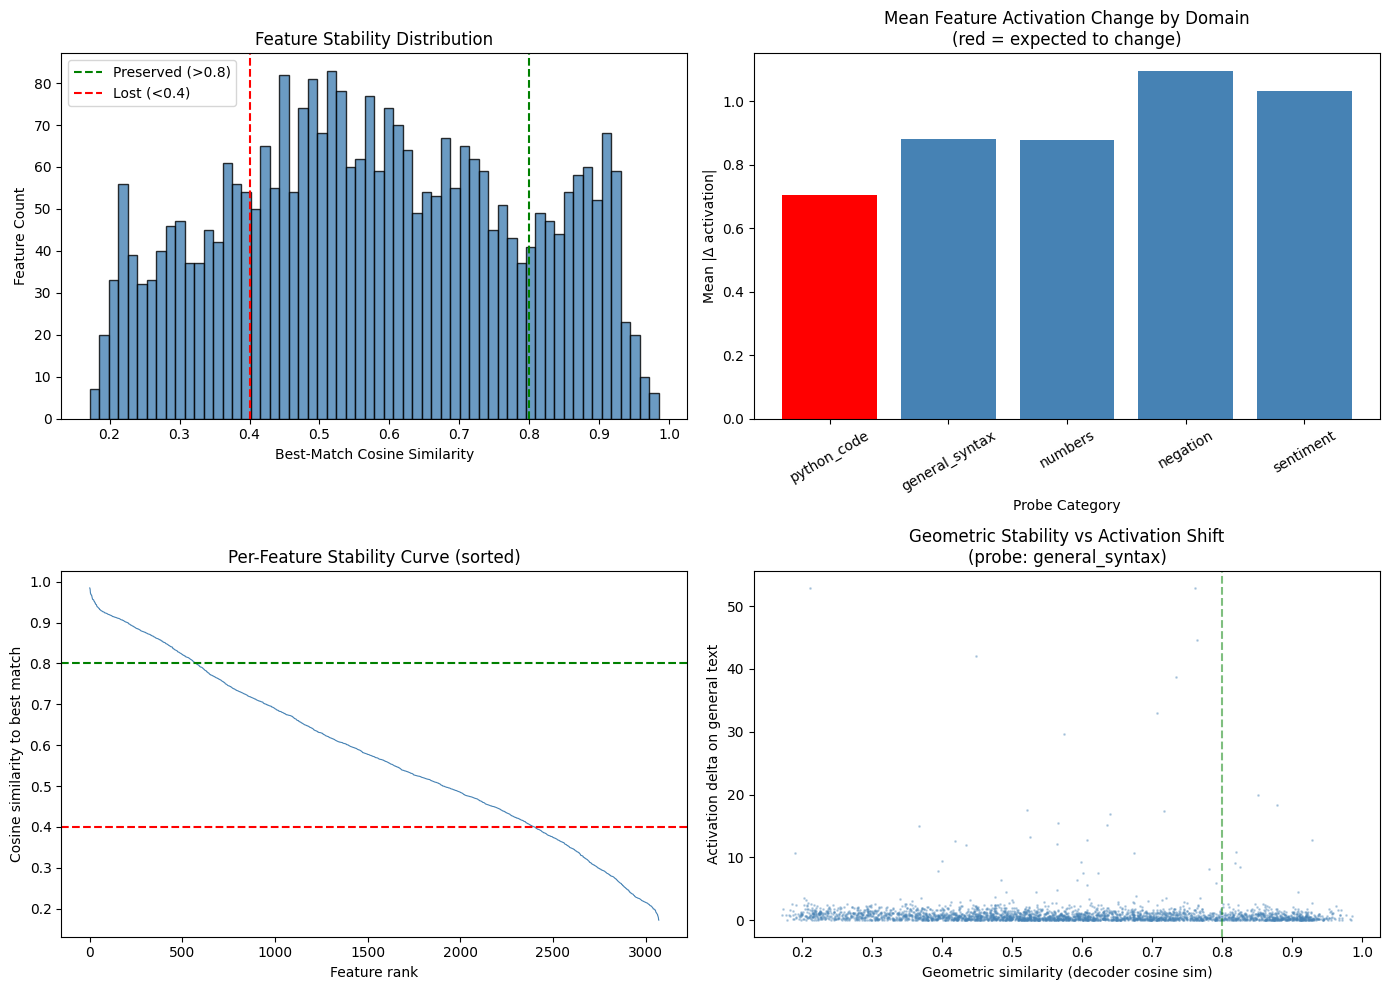

In [75]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Main histogram
axes[0,0].hist(best_match_score.numpy(), bins=60, color='steelblue', edgecolor='black', alpha=0.8)
axes[0,0].axvline(x=0.8, color='green', linestyle='--', label='Preserved (>0.8)')
axes[0,0].axvline(x=0.4, color='red',   linestyle='--', label='Lost (<0.4)')
axes[0,0].set_title("Feature Stability Distribution")
axes[0,0].set_xlabel("Best-Match Cosine Similarity")
axes[0,0].set_ylabel("Feature Count")
axes[0,0].legend()


categories = list(results.keys())
mean_deltas = [
    (results[c]["ft"] - results[c]["base"]).abs().mean().item()
    for c in categories
]
colors = ['red' if c == 'python_code' else 'steelblue' for c in categories]
axes[0,1].bar(categories, mean_deltas, color=colors)
axes[0,1].set_title("Mean Feature Activation Change by Domain\n(red = expected to change)")
axes[0,1].set_xlabel("Probe Category")
axes[0,1].set_ylabel("Mean |Δ activation|")
axes[0,1].tick_params(axis='x', rotation=30)


sorted_scores, _ = best_match_score.sort(descending=True)
axes[1,0].plot(sorted_scores.numpy(), color='steelblue', linewidth=0.8)
axes[1,0].axhline(y=0.8, color='green', linestyle='--')
axes[1,0].axhline(y=0.4, color='red',   linestyle='--')
axes[1,0].set_title("Per-Feature Stability Curve (sorted)")
axes[1,0].set_xlabel("Feature rank")
axes[1,0].set_ylabel("Cosine similarity to best match")


cat = "general_syntax"
geo_sims  = best_match_score.numpy()
act_delta = (results[cat]["ft"] - results[cat]["base"]).abs().numpy()
axes[1,1].scatter(geo_sims, act_delta, s=1, alpha=0.3, color='steelblue')
axes[1,1].set_title(f"Geometric Stability vs Activation Shift\n(probe: {cat})")
axes[1,1].set_xlabel("Geometric similarity (decoder cosine sim)")
axes[1,1].set_ylabel("Activation delta on general text")
axes[1,1].axvline(x=0.8, color='green', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("full_analysis.png", dpi=300)
print("Saved full_analysis.png")

In [76]:
model = HookedTransformer.from_pretrained("pythia-160m", device="cpu")
state = torch.load("/kaggle/input/datasets/ritwik8307/sae-pythia-checkpoints/final_sae.pt",
                   map_location="cpu")
W_enc = state["W_enc"].float()
b_enc = state["b_enc"].float()

K = 20
n_features = W_enc.shape[1]
top_acts   = torch.full((n_features, K), -1.0)
top_tokens = [[""] * K for _ in range(n_features)]
top_contexts = [[""] * K for _ in range(n_features)]

dataset = load_dataset("Skylion007/openwebtext", split="train", streaming=True)

for ex_idx, example in enumerate(dataset):
    if ex_idx >= 300: break

    text = example["text"][:400]
    tokens = model.to_tokens(text, prepend_bos=True)
    token_strs = model.to_str_tokens(tokens[0]) 

    with torch.no_grad():
        _, cache = model.run_with_cache(tokens)
        acts = cache["blocks.8.hook_resid_post"].squeeze(0)


    hidden = torch.relu(acts @ W_enc + b_enc)

    for tok_pos in range(hidden.shape[0]):
        firing = hidden[tok_pos].nonzero(as_tuple=True)[0] 
        for feat_idx in firing:
            feat_idx = feat_idx.item()
            val = hidden[tok_pos, feat_idx].item()
            start = max(0, tok_pos - 3)
            end   = min(len(token_strs), tok_pos + 4)
            context = "".join(token_strs[start:end])
            current_tok = token_strs[tok_pos]

            min_val, min_pos = top_acts[feat_idx].min(dim=0)
            if val > min_val.item():
                top_acts[feat_idx, min_pos] = val
                top_tokens[feat_idx][min_pos] = current_tok
                top_contexts[feat_idx][min_pos] = context

    if ex_idx % 50 == 0:
        print(f"Processed {ex_idx}/300 examples...")

print("Done collecting feature activations.")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded pretrained model pythia-160m into HookedTransformer


Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

Processed 0/300 examples...
Processed 50/300 examples...
Processed 100/300 examples...
Processed 150/300 examples...
Processed 200/300 examples...
Processed 250/300 examples...
Done collecting feature activations.


In [77]:
model_ft = HookedTransformer.from_pretrained("pythia-160m", device="cpu")

# Load finetuned model weights into HookedTransformer
from transformers import AutoModelForCausalLM
ft_hf_model = AutoModelForCausalLM.from_pretrained("/kaggle/input/datasets/ritwik8307/pythia-python-finetuned/final_model")
model_ft.load_state_dict(ft_hf_model.state_dict(), strict=False)

state_ft = torch.load("/kaggle/input/datasets/ritwik8307/sae-finetuned-checkpoints/final_ft_sae.pt", map_location="cpu")
W_enc_ft = state_ft["W_enc"].float()
b_enc_ft = state_ft["b_enc"].float()

K = 20
n_features_ft = W_enc_ft.shape[1]
top_acts_ft     = torch.full((n_features_ft, K), -1.0)
top_tokens_ft   = [[""] * K for _ in range(n_features_ft)]
top_contexts_ft = [[""] * K for _ in range(n_features_ft)]

dataset = load_dataset("Skylion007/openwebtext", split="train", streaming=True)

for ex_idx, example in enumerate(dataset):
    if ex_idx >= 300: break
    text = example["text"][:400]
    tokens = model_ft.to_tokens(text, prepend_bos=True)
    token_strs = model_ft.to_str_tokens(tokens[0])

    with torch.no_grad():
        _, cache = model_ft.run_with_cache(tokens)
        acts = cache["blocks.8.hook_resid_post"].squeeze(0)  # [n_tokens, 768]

    hidden = torch.relu(acts @ W_enc_ft + b_enc_ft)  # [n_tokens, n_features]

    for tok_pos in range(hidden.shape[0]):
        firing = hidden[tok_pos].nonzero(as_tuple=True)[0]
        for feat_idx in firing:
            feat_idx = feat_idx.item()
            val = hidden[tok_pos, feat_idx].item()

            start = max(0, tok_pos - 3)
            end   = min(len(token_strs), tok_pos + 4)
            context = "".join(token_strs[start:end])
            current_tok = token_strs[tok_pos]

            min_val, min_pos = top_acts_ft[feat_idx].min(dim=0)
            if val > min_val.item():
                top_acts_ft[feat_idx, min_pos] = val
                top_tokens_ft[feat_idx][min_pos] = current_tok
                top_contexts_ft[feat_idx][min_pos] = context

    if ex_idx % 50 == 0:
        print(f"Processed {ex_idx}/300 examples...")

print("Done collecting finetuned feature activations.")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded pretrained model pythia-160m into HookedTransformer


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

Processed 0/300 examples...
Processed 50/300 examples...
Processed 100/300 examples...
Processed 150/300 examples...
Processed 200/300 examples...
Processed 250/300 examples...
Done collecting finetuned feature activations.


In [78]:
def inspect_feature(feat_idx):
    acts_for_feat = top_acts[feat_idx]

    # Check if feature ever fired
    if acts_for_feat.max().item() < 0:
        print(f"Feature {feat_idx}: DEAD — never fired")
        return

    # Sort by activation strength
    sorted_vals, sorted_pos = acts_for_feat.sort(descending=True)

    print(f"\n{'='*50}")
    print(f"Feature {feat_idx}")
    print(f"{'='*50}")
    print(f"Max activation: {sorted_vals[0].item():.3f}")
    print(f"\nTop activating tokens and contexts:")

    for rank in range(K):
        val = sorted_vals[rank].item()
        if val < 0: break
        pos = sorted_pos[rank].item()
        tok = top_tokens[feat_idx][pos]
        ctx = top_contexts[feat_idx][pos]
        print(f"  {rank+1:2d}. [{val:.3f}] token='{tok}'  context='{ctx}'")

In [84]:

import random
for idx in random.sample(range(n_features), 10):
    inspect_feature(idx)


Feature 952
Max activation: 8.834

Top activating tokens and contexts:
   1. [8.834] token=':'  context='. For example:

vector'
   2. [8.542] token=':'  context=' is available at: miraj-'
   3. [8.469] token=' );'  context=' string & text );

Here'
   4. [7.070] token='
'  context=' For example:

vector <'
   5. [6.486] token='
'  context=' example:

vector < string'
   6. [6.261] token=' at'  context=' code are available at miraj-'
   7. [5.350] token=':'  context=' files are necessary: (1)'
   8. [5.162] token='…'  context=' the first half…

U'
   9. [5.035] token='https'  context=' legal repository (https://ssl.'
  10. [4.986] token='
'  context=' text );

Here, we'
  11. [4.854] token=' at'  context=' code is available at: miraj'
  12. [4.844] token=':'  context='selected Winners:

Angel'
  13. [4.752] token=':'  context=' guy's requirements:

Exper'
  14. [4.710] token='
'  context=' & text );

Here,'
  15. [4.523] token=':'  context=' was the solution: open each link'
  16. [4.

In [80]:
#FOR SPECIFIC CATEGORIES


def find_features_for_concept(probe_sentences, top_k=10, threshold=0.5):
    """
    Given probe sentences, find which features fire most consistently.
    Use this to identify what concept a group of features represents.
    """
    feature_scores = torch.zeros(n_features)

    for text in probe_sentences:
        tokens = model.to_tokens(text, prepend_bos=True)
        with torch.no_grad():
            _, cache = model.run_with_cache(tokens)
            acts = cache["blocks.8.hook_resid_post"].squeeze(0)
        hidden = torch.relu(acts @ W_enc + b_enc)

        feature_scores += hidden.mean(dim=0)

    feature_scores /= len(probe_sentences)


    top_features = feature_scores.topk(top_k)
    print(f"\nTop {top_k} features:")
    for val, idx in zip(top_features.values, top_features.indices):
        print(f"  Feature {idx.item():4d}: mean_activation={val.item():.4f}")
        acts_for_feat = top_acts[idx.item()]
        sorted_vals, sorted_pos = acts_for_feat.sort(descending=True)
        top_toks = [top_tokens[idx.item()][p] for p in sorted_pos[:5].tolist()]
        print(f"            top tokens: {top_toks}")

    return top_features.indices



In [81]:

print("=== PYTHON CODE FEATURES ===")
python_features = find_features_for_concept([
    "def fibonacci(n):",
    "import numpy as np",
    "for i in range(10):",
    "class MyClass(object):",
    "return self.value",
])

# Find general syntax features (should be stable)
print("\n=== NEGATION FEATURES ===")
negation_features = find_features_for_concept([
    "This is not correct.",
    "He never said that.",
    "I don't believe this.",
    "She couldn't understand why.",
])

# Find number features
print("\n=== NUMBER FEATURES ===")
number_features = find_features_for_concept([
    "In 1945 the war ended.",
    "There are 42 students.",
    "The price is $19.99.",
    "He scored 98 out of 100.",
])

=== PYTHON CODE FEATURES ===

Top 10 features:
  Feature 2827: mean_activation=39.5840
            top tokens: ['\n', '.', '\n', '\n', '\n']
  Feature 2690: mean_activation=35.9194
            top tokens: ['\n', '\n', '\n', '\n', '\n']
  Feature 2804: mean_activation=22.7647
            top tokens: ['\n', '\n', '\n', '\n', '\n']
  Feature 2108: mean_activation=16.3226
            top tokens: ['\n', '\n', '\n', '\n', '\n']
  Feature  435: mean_activation=12.0665
            top tokens: ['\n', '\n', '\n', '\n', '\n']
  Feature 1580: mean_activation=11.0799
            top tokens: ['\n', '\n', '\n', '\n', '\n']
  Feature 2598: mean_activation=10.9032
            top tokens: ['\n', '\n', '\n', '\n', '\n']
  Feature 2675: mean_activation=10.8274
            top tokens: ['\n', '\n', '\n', '\n', '\n']
  Feature  314: mean_activation=10.8258
            top tokens: ['\n', '\n', '\n', '\n', '\n']
  Feature 2304: mean_activation=10.7915
            top tokens: ['\n', '\n', '\n', '\n', '\n']

===

In [91]:
def compare_feature_across_saes(feat_idx, top_tokens_base, top_tokens_ft,
                                  top_acts_base, top_acts_ft):
    """
    Show what feature feat_idx responds to in base vs fine-tuned SAE.
    Use the best_match_idx to find the corresponding feature in SAE #2.
    """
    # Find matched feature in SAE #2
    matched_feat_idx = best_match_idx[feat_idx].item()
    match_score      = best_match_score[feat_idx].item()

    print(f"\n{'='*60}")
    print(f"Base SAE — Feature {feat_idx}  |  "
          f"Best match in Fine-tuned SAE — Feature {matched_feat_idx}  |  "
          f"Cosine sim: {match_score:.3f}")
    print(f"{'='*60}")

    # Base feature top tokens
    sorted_base = top_acts_base[feat_idx].sort(descending=True)
    print(f"\n[BASE] Top tokens:")
    for rank in range(10):
        val = sorted_base.values[rank].item()
        if val < 0: break
        pos = sorted_base.indices[rank].item()
        tok = top_tokens_base[feat_idx][pos]
        ctx = top_contexts[feat_idx][pos]
        print(f"  {rank+1:2d}. [{val:.3f}] '{tok}'  —  '{ctx}'")

    # Fine-tuned feature top tokens
    sorted_ft = top_acts_ft[matched_feat_idx].sort(descending=True)
    print(f"\n[FINE-TUNED] Top tokens (matched feature {matched_feat_idx}):")
    for rank in range(10):
        val = sorted_ft.values[rank].item()
        if val < 0: break
        pos = sorted_ft.indices[rank].item()
        tok = top_tokens_ft[matched_feat_idx][pos]
        ctx = top_contexts_ft[matched_feat_idx][pos]
        print(f"  {rank+1:2d}. [{val:.3f}] '{tok}'  —  '{ctx}'")

    # Verdict
    if match_score > 0.8:
        print(f"\n PRESERVED — feature kept same meaning after fine-tuning")
    elif match_score > 0.4:
        print(f"\n  SHIFTED — feature direction changed moderately")
    else:
        print(f"\n LOST — no geometrically similar feature found in SAE #2")

In [92]:

# 1. Features you expect to change — from python_features list
for idx in python_features[:3].tolist():
    compare_feature_across_saes(idx, top_tokens, top_tokens_ft,
                                 top_acts, top_acts_ft)

# 2. Features you expect to be stable — from negation_features
for idx in negation_features[:3].tolist():
    compare_feature_across_saes(idx, top_tokens, top_tokens_ft,
                                 top_acts, top_acts_ft)

# 3. The single most preserved feature (best_match_score.argmax())
best_preserved = best_match_score.argmax().item()
compare_feature_across_saes(best_preserved, top_tokens, top_tokens_ft,
                              top_acts, top_acts_ft)

# 4. A clearly lost feature
lost_idx = (best_match_score < 0.2).nonzero()[0].item()
compare_feature_across_saes(lost_idx, top_tokens, top_tokens_ft,
                              top_acts, top_acts_ft)


Base SAE — Feature 2827  |  Best match in Fine-tuned SAE — Feature 2241  |  Cosine sim: 0.764

[BASE] Top tokens:
   1. [141.325] '
'  —  ' Brown writes,

At London'
   2. [140.705] '.'  —  ' earlier on tonight. The postman'
   3. [140.679] '
'  —  '58 IST

J '
   4. [140.519] '
'  —  'Hello there,

We’'
   5. [140.480] '
'  —  ' acts were found

She will'
   6. [140.325] '
'  —  ' from anyone else

3D'
   7. [140.245] '.'  —  '! I know. That’s'
   8. [140.134] '.'  —  ' Arsenal is different. That, at'
   9. [140.051] '
'  —  'th, 2017

Wests'
  10. [139.808] '.'  —  ' into a bar. They order beers'

[FINE-TUNED] Top tokens (matched feature 2241):
   1. [63.891] '<|endoftext|>'  —  '<|endoftext|>Ready to fight'
   2. [63.891] '<|endoftext|>'  —  '<|endoftext|>Ad blockers are'
   3. [63.891] '<|endoftext|>'  —  '<|endoftext|>North Korean leader'
   4. [63.891] '<|endoftext|>'  —  '<|endoftext|>WHAT?!??'
   5. [63.891] '<|endoftext|>'  —  '<|endoftext|>About This Game'
   6. [63.891] '<|